In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from datetime import datetime

--- SUCCESS ---
Estimated Price for 2025-01-15: $13.13


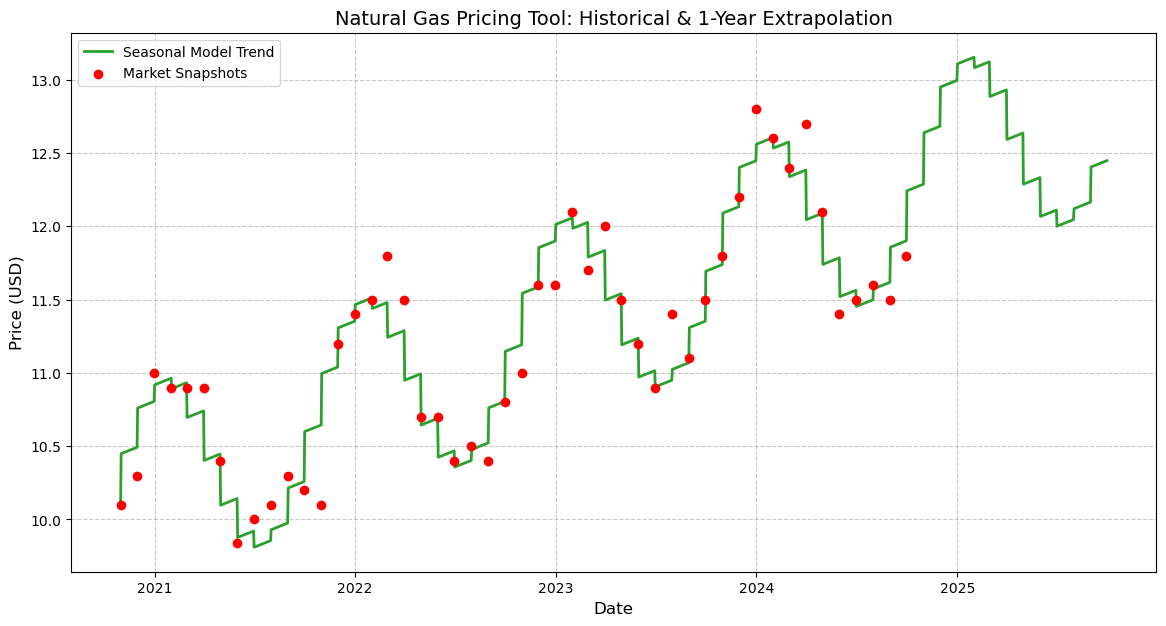

In [14]:
# =========================================
# OPTIONAL: AUTO-CREATE FILE (Uncomment if needed)
# ==========================================
"""
data = {
    'Dates': ['10/31/2020', '11/30/2020', '12/31/2020', '1/31/2021', '2/28/2021', '3/31/2021'],
    'Prices': [10.1, 10.3, 11.0, 10.9, 10.9, 10.9]
}
pd.DataFrame(data).to_csv('Nat_Gas.csv', index=False)
"""

class GasPriceModel:
    def __init__(self, csv_path):
        # Load data and handle potential scientific notation automatically
        self.df = pd.read_csv(csv_path)
        self.df['Dates'] = pd.to_datetime(self.df['Dates'])
        self.df['Prices'] = self.df['Prices'].astype(float)
        
        # Initialize the regression model (Note the capital L and R)
        self.model = LinearRegression()
        self.start_date = self.df['Dates'].min()
        
        # Train immediately upon initialization
        self._train()

    def _prepare_features(self, date_series):
        """
        Converts dates into mathematical features:
        1. Trend: Days from start (linear)
        2. Seasonality: Sine/Cosine transformation of the month
        """
        # Linear trend
        days_from_start = (date_series - self.start_date).dt.days
        
        # Monthly seasonality
        month = date_series.dt.month
        sin_month = np.sin(2 * np.pi * month / 12)
        cos_month = np.cos(2 * np.pi * month / 12)
        
        return pd.DataFrame({
            'trend': days_from_start,
            'sin': sin_month,
            'cos': cos_month
        })

    def _train(self):
        """Internal method to fit the model to our CSV data."""
        X = self._prepare_features(self.df['Dates'])
        y = self.df['Prices']
        self.model.fit(X, y)

    def predict_price(self, target_date):
        """Returns a rounded price estimate for any input date string."""
        target_dt = pd.to_datetime(target_date)
        features = self._prepare_features(pd.Series([target_dt]))
        prediction = self.model.predict(features)
        return round(prediction[0], 2)

    def plot_analysis(self, months_to_extrapolate=12):
        """Generates a visual of historical data and future predictions."""
        # Create a range of dates from the beginning of our data to 1 year in the future
        last_date = self.df['Dates'].max()
        future_limit = last_date + pd.DateOffset(months=months_to_extrapolate)
        
        # Daily range for a smooth curve
        plot_dates = pd.date_range(start=self.start_date, end=future_limit, freq='D')
        
        # Predict prices for every day in that range
        plot_features = self._prepare_features(pd.Series(plot_dates))
        predicted_prices = self.model.predict(plot_features)
        
        plt.figure(figsize=(14, 7))
        
        # Plot the smooth prediction line
        plt.plot(plot_dates, predicted_prices, label='Seasonal Model Trend', color='#2ca02c', linewidth=2)
        
        # Plot the actual historical data points
        plt.scatter(self.df['Dates'], self.df['Prices'], color='red', label='Market Snapshots', zorder=5)
        
        plt.title('Natural Gas Pricing Tool: Historical & 1-Year Extrapolation', fontsize=14)
        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Price (USD)', fontsize=12)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

# --- Practical Usage ---
try:
    # Use the absolute path if you still get FileNotFoundError, 
    # e.g., r'C:\Users\YourName\Documents\Nat_Gas.csv'
    pricing_tool = GasPriceModel('Nat_Gas.csv')
    
    # Example 1: Predict a specific date
    date_to_check = "2025-01-15"
    price_est = pricing_tool.predict_price(date_to_check)
    print(f"--- SUCCESS ---")
    print(f"Estimated Price for {date_to_check}: ${price_est}")
    
    # Example 2: Show the visual trend
    pricing_tool.plot_analysis()

except FileNotFoundError:
    print("--- ERROR ---")
    print("Could not find 'Nat_Gas.csv'. Ensure the file is in the same folder as this script.")
except Exception as e:
    print(f"--- AN UNEXPECTED ERROR OCCURRED ---")
    print(e)

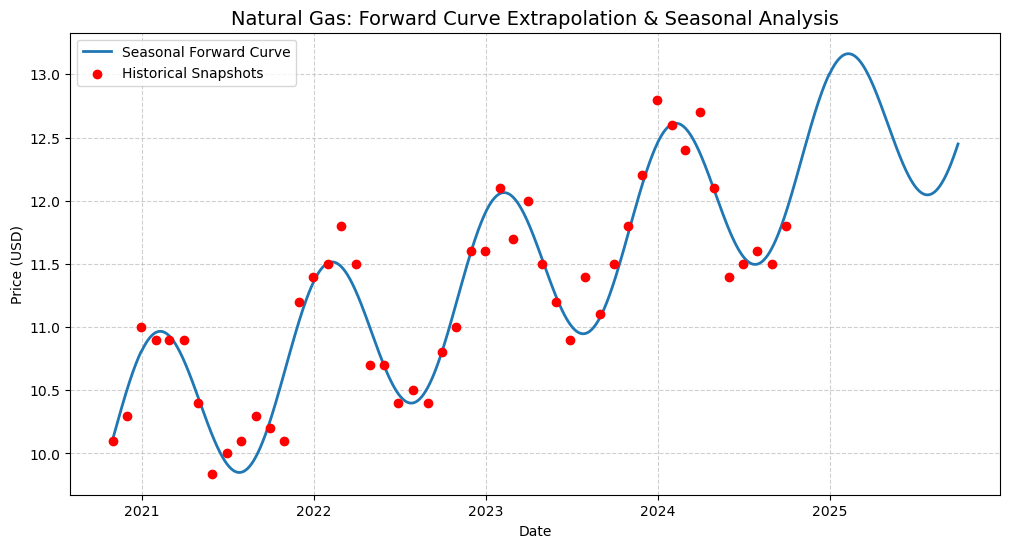

--- QUANTITATIVE ANALYSIS COMPLETE ---
Estimated Price (Dec 2025): $13.4
Contract NPV: $1,065,000.0


In [16]:


class GasTradingEngine:
    def __init__(self, csv_filename):
        # 1. Load data from the same folder
        self.df = pd.read_csv(csv_filename)
        self.df['Dates'] = pd.to_datetime(self.df['Dates'])
        self.df['Prices'] = self.df['Prices'].astype(float)
        
        # 2. Setup Model
        self.model = LinearRegression()
        self.start_date = self.df['Dates'].min()
        
        # 3. Train immediately
        self._train()

    def _prepare_features(self, date_series):
        """Converts dates into trend and smooth seasonal features."""
        # Feature 1: Linear Trend
        days_from_start = (date_series - self.start_date).dt.days
        
        # Feature 2 & 3: Smooth Seasonality (using day of year)
        day_of_year = date_series.dt.dayofyear
        sin_seasonal = np.sin(2 * np.pi * day_of_year / 365.25)
        cos_seasonal = np.cos(2 * np.pi * day_of_year / 365.25)
        
        return pd.DataFrame({
            'trend': days_from_start,
            'sin': sin_seasonal,
            'cos': cos_seasonal
        })

    def _train(self):
        """Fits the linear regression to historical market data."""
        X = self._prepare_features(self.df['Dates'])
        y = self.df['Prices']
        self.model.fit(X, y)

    def get_price_estimate(self, date_string):
        """Predicts the gas price for any given date."""
        target_dt = pd.to_datetime(date_string)
        features = self._prepare_features(pd.Series([target_dt]))
        prediction = self.model.predict(features)
        return round(prediction[0], 2)

    def calculate_contract_value(self, injection_date, withdrawal_date, volume, 
                                 storage_rate, inj_fee, with_fee, annual_rate):
        """
        Calculates the Net Present Value (NPV) of a storage contract.
        """
        # Get market prices
        p_inj = self.get_price_estimate(injection_date)
        p_with = self.get_price_estimate(withdrawal_date)
        
        # Calculate storage duration
        start_dt = pd.to_datetime(injection_date)
        end_dt = pd.to_datetime(withdrawal_date)
        months_stored = (end_dt.year - start_dt.year) * 12 + (end_dt.month - start_dt.month)
        
        # Physical Cash Flows
        injection_cost = (p_inj + inj_fee) * volume
        withdrawal_revenue = (p_with - with_fee) * volume
        total_storage_fees = storage_rate * months_stored
        
        gross_profit = withdrawal_revenue - injection_cost - total_storage_fees
        
        # Financial Discounting (NPV)
        # We assume 'today' is the baseline for discounting
        days_to_withdrawal = (end_dt - pd.Timestamp.now()).days
        years_to_withdrawal = max(0, days_to_withdrawal / 365.25)
        
        npv = gross_profit / ((1 + annual_rate) ** years_to_withdrawal)
        return round(npv, 2)

    def plot_market_analysis(self):
        """Generates a visual forward curve for the trading desk."""
        last_date = self.df['Dates'].max()
        # Project 1 year into the future
        future_dates = pd.date_range(start=self.start_date, end=last_date + pd.DateOffset(years=1), freq='D')
        
        X_plot = self._prepare_features(pd.Series(future_dates))
        y_plot = self.model.predict(X_plot)
        
        plt.figure(figsize=(12, 6))
        plt.plot(future_dates, y_plot, label='Seasonal Forward Curve', color='#1f77b4', linewidth=2)
        plt.scatter(self.df['Dates'], self.df['Prices'], color='red', label='Historical Snapshots', zorder=5)
        
        plt.title('Natural Gas: Forward Curve Extrapolation & Seasonal Analysis', fontsize=14)
        plt.xlabel('Date')
        plt.ylabel('Price (USD)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    try:
        # 1. Initialize the engine
        engine = GasTradingEngine('Nat_Gas.csv')
        
        # 2. View the Curve
        engine.plot_market_analysis()
        
        # 3. Calculate a Sample Contract
        # Scenario: Buy in Summer 2025, Sell in Winter 2025
        npv_result = engine.calculate_contract_value(
            injection_date='2025-07-01', 
            withdrawal_date='2025-12-15', 
            volume=1000000, 
            storage_rate=5000, 
            inj_fee=0.10, 
            with_fee=0.10, 
            annual_rate=0.05
        )
        
        print(f"--- QUANTITATIVE ANALYSIS COMPLETE ---")
        print(f"Estimated Price (Dec 2025): ${engine.get_price_estimate('2025-12-15')}")
        print(f"Contract NPV: ${npv_result:,}")

    except Exception as e:
        print(f"Error: {e}")